## 1

Compute pi-number using the recursive program for the following formula through generalized
continuous fractions:

Begin with obtaining the “numerically exact” solution comparing results with n and n + 1 terms,
until error stops decreasing (show both absolute and relative errors). Show linear convergence with
number of terms, comparing with “numerically exact” solution and between successive approximations. Use double logarithmic plot (logarithm of both coordinates). Why are you supposed to get
a linear function? What will happen if the rate of convergence will be a quadratic one? Why linear
dependence is observed only on a finite interval?

Numerically exact solution:
pi = 3.1415926535897931
Convergence stops at n = 22
|pi_(n+1) - pi_n| = 0.000e+00

 n        pi_n                  abs error        rel error
   1   4.000000000000000   8.584e-01   2.732e-01
   2   3.000000000000000   1.416e-01   4.507e-02
   3   3.166666666666667   2.507e-02   7.981e-03
   4   3.137254901960785   4.338e-03   1.381e-03
   5   3.142342342342342   7.497e-04   2.386e-04
   6   3.141463414634146   1.292e-04   4.114e-05
   7   3.141614906832298   2.225e-05   7.083e-06
   8   3.141588825092124   3.828e-06   1.219e-06
   9   3.141593311879928   6.583e-07   2.095e-07
  10   3.141592540446540   1.131e-07   3.601e-08
  11   3.141592673030334   1.944e-08   6.188e-09
  12   3.141592650250245   3.340e-09   1.063e-09
  13   3.141592654163366   5.736e-10   1.826e-10
  14   3.141592653491295   9.850e-11   3.135e-11
  15   3.141592653606706   1.691e-11   5.384e-12
  16   3.141592653586889   2.904e-12   9.243e-13
  17   3.141592653590292   4.987e-13   1.587e-

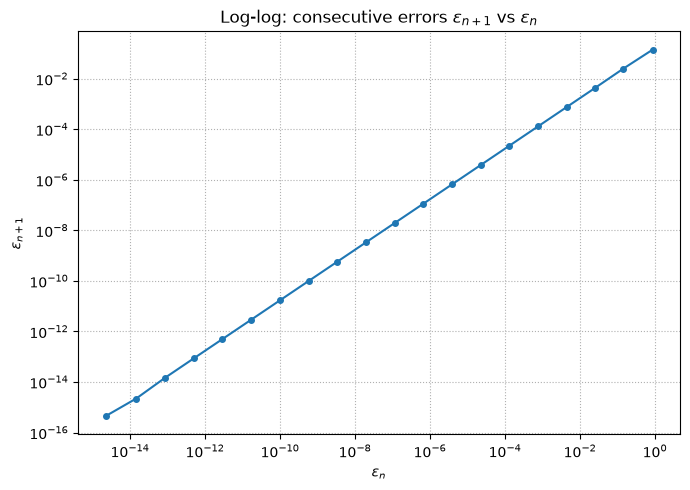

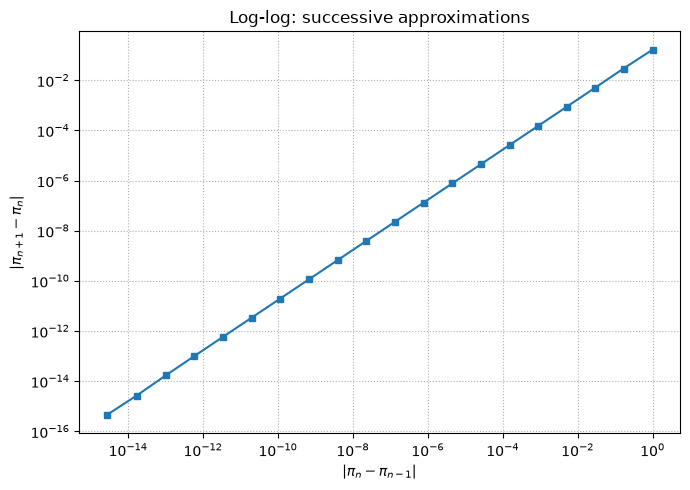

In [54]:
import math
import numpy as np
import matplotlib.pyplot as plt

def compute_pi(n):
    frac = float(2 * n - 1)
    for k in range(n - 1, 0, -1):
        frac = (2 * k - 1) + k**2 / frac
    return 4.0 / frac

N = 30
n = np.arange(1, N + 1)
pi_n = np.array([compute_pi(i) for i in n])
pi_exact = math.pi


abs_error = np.abs(pi_n - pi_exact)
rel_error = abs_error / abs(pi_exact)


successive_diff = np.abs(np.diff(pi_n))


k_stop = np.argmin(successive_diff)
print("Numerically exact solution:")
print(f"pi = {pi_exact:.16f}")
print(f"Convergence stops at n = {k_stop + 1}")
print(f"|pi_(n+1) - pi_n| = {successive_diff[k_stop]:.3e}")
print()
print(" n        pi_n                  abs error        rel error")
for i in range(N):
    print(f"{i+1:4d}   {pi_n[i]:.15f}   {abs_error[i]:.3e}   {rel_error[i]:.3e}")


eps = abs_error[abs_error > 0]
plt.figure(figsize=(7, 5))
plt.loglog(eps[:-1], eps[1:], "o-", markersize=4)
plt.xlabel(r"$\varepsilon_n$")
plt.ylabel(r"$\varepsilon_{n+1}$")
plt.title("Log-log: consecutive errors $\\varepsilon_{n+1}$ vs $\\varepsilon_n$")
plt.grid(True, which="both", linestyle=":")
plt.tight_layout()
plt.show()


diffs = successive_diff[successive_diff > 0]
plt.figure(figsize=(7, 5))
plt.loglog(diffs[:-1], diffs[1:], "s-", markersize=4)
plt.xlabel(r"$|\pi_n - \pi_{n-1}|$")
plt.ylabel(r"$|\pi_{n+1} - \pi_n|$")
plt.title("Log-log: successive approximations")
plt.grid(True, which="both", linestyle=":")
plt.tight_layout()
plt.show()


## 4
Consider a right triangle whose legs are of length 3344556600 and 1.2222222. How much
longer is the hypotenuse than the longer leg? Give your answer with at least four correct
digits.

In [ ]:
import math

a = 3344556600
b = 1.2222222

difference = b ** 2 / (math.sqrt(a**2 + b**2) + a)

print(difference)

# output 2.2332214473105944e-10

2.2332214473105944e-10


In [2]:
a = 3344556600
b = 1.2222222

difference = math.sqrt(a**2 + b**2) - a

print(difference)

0.0


## 5

Use the bisection method to compute a positive real number x satisfying sinh x = cos x with
a tolerance of 10−8
. List your initial interval in the case of bisection and the number of required
iterations. Also print at least nine digits of the approximate root.

In [6]:
a = 0
b = 1
iterations = 0
def f(x):
    return math.sinh(x) - math.cos(x)


m = (a + b) / 2
while (b - a) / 2 > 1e-8:
    m = (a + b) / 2

    if f(m) < 0:
        a = m
    else:
        b = m

    iterations += 1

print(f"x = {m}, f(x) = {f(m)}, iterations = {iterations}")

x = 0.703290656208992, f(x) = -5.056139507075841e-09, iterations = 26


## 9

Apply Newton’s Method to find both roots of the function f (x) = 14xex−2 − 12ex−2 −
7x3 + 20x2 − 26x + 12 on the interval [0,3]. For each root, print out the sequence of iterates,
the errors ei, and the relevant error ratio ei+1/e2
i or ei+1/ei that converges to a nonzero limit.
Match the limit with the expected value M from Theorem 1.11 or S from Theorem 1.12.

In [22]:
import math

def f(x):
    return 14*x*math.exp(x-2) - 12*math.exp(x-2) - 7*x**3 + 20*x**2 - 26*x + 12

def df(x):
    return 14*math.exp(x-2) + 14*x*math.exp(x-2) \
           - 12*math.exp(x-2) - 21*x**2 + 40*x - 26


def newton(x0, n):
    x = x0

    print(f"x0 = {x0}")

    for i in range(n):
        x = x - f(x) / df(x)
        print(i, x)

newton(3, 20)


x0 = 3
0 2.7338502571320995
1 2.529771874045484
2 2.3766658229690543
3 2.264145581220574
4 2.183030922118089
5 2.1255657773577505
6 2.0854615043527582
7 2.057814950176053
8 2.038938028160986
9 2.026140999384837
10 2.0175105386621683
11 2.0117113478603845
12 2.007824507284031
13 2.0052239304287878
14 2.0034860134043493
15 2.002325522624122
16 2.001551023012529
17 2.0010343150515664
18 2.000689677414062
19 2.0004598408486887


In [25]:
newton(1, 20)

x0 = 1
0 0.7627845835848802
1 0.840821691829043
2 0.8565332220104341
3 0.8571419618530481
4 0.8571428571409215
5 0.857142857142857
6 0.8571428571428577
7 0.8571428571428563
8 0.8571428571428577
9 0.8571428571428563
10 0.8571428571428577
11 0.8571428571428563
12 0.8571428571428577
13 0.8571428571428563
14 0.8571428571428577
15 0.8571428571428563
16 0.8571428571428577
17 0.8571428571428563
18 0.8571428571428577
19 0.8571428571428563


In [27]:
def ddf(x):
    return 28*math.exp(x-2) + 14*x*math.exp(x-2) \
           - 12*math.exp(x-2) - 42*x + 40

def dddf(x):
    return 30 * math.exp(x - 2) + 14 * x * math.exp(x - 2) - 42

# print(f"M={ddf(2) / (2 * df(2))}")  error as the f'(x) = 0, so the root is not primary

print(f(2))
print(df(2))
print(ddf(2))
print(dddf(2))

0.0
0.0
0.0
16.0


In [29]:
print(f(6/7))
print(df(6/7))

0.0
-2.6781653403215557


In [36]:
def newton_w_errors(x0, n, root=2):
    x = x0
    errors = []

    print(f"x0 = {x0}")

    for i in range(n):
        e = abs(x - root)
        errors.append(e)

        if i == 0:
            print(f"i={i}: x={x:.12f}, e={e:.12e}")
        elif i == 1:
            ratio_lin = errors[-1] / errors[-2]
            print(f"i={i}: x={x:.12f}, e={e:.12e}, "
                  f"e_i/e_(i-1)={ratio_lin:.12e}")
        else:
            ratio_lin  = errors[-1] / errors[-2]
            ratio_quad = errors[-1] / errors[-2]**2
            print(f"i={i}: x={x:.12f}, e={e:.12e}, "
                  f"e_i/e_(i-1)={ratio_lin:.12e}, "
                  f"e_i/e_(i-1)^2={ratio_quad:.12e}")

        x = x - f(x) / df(x)


newton_w_errors(3, 20, 2)

x0 = 3
i=0: x=3.000000000000, e=1.000000000000e+00
i=1: x=2.733850257132, e=7.338502571321e-01, e_i/e_(i-1)=7.338502571321e-01
i=2: x=2.529771874045, e=5.297718740455e-01, e_i/e_(i-1)=7.219073222320e-01, e_i/e_(i-1)^2=9.837256514063e-01
i=3: x=2.376665822969, e=3.766658229691e-01, e_i/e_(i-1)=7.109962635289e-01, e_i/e_(i-1)^2=1.342080050607e+00
i=4: x=2.264145581221, e=2.641455812206e-01, e_i/e_(i-1)=7.012730253530e-01, e_i/e_(i-1)^2=1.861790963208e+00
i=5: x=2.183030922118, e=1.830309221181e-01, e_i/e_(i-1)=6.929168425697e-01, e_i/e_(i-1)^2=2.623238440589e+00
i=6: x=2.125565777358, e=1.255657773578e-01, e_i/e_(i-1)=6.860358670801e-01, e_i/e_(i-1)^2=3.748196529532e+00
i=7: x=2.085461504353, e=8.546150435276e-02, e_i/e_(i-1)=6.806114384915e-01, e_i/e_(i-1)^2=5.420357782299e+00
i=8: x=2.057814950176, e=5.781495017605e-02, e_i/e_(i-1)=6.765028373174e-01, e_i/e_(i-1)^2=7.915877943419e+00
i=9: x=2.038938028161, e=3.893802816099e-02, e_i/e_(i-1)=6.734941056321e-01, e_i/e_(i-1)^2=1.1649134066

In [39]:
newton_w_errors(1, 20, 6/7)

x0 = 1
i=0: x=1.000000000000, e=1.428571428571e-01
i=1: x=0.762784583585, e=9.435827355798e-02, e_i/e_(i-1)=6.605079149058e-01
i=2: x=0.840821691829, e=1.632116531381e-02, e_i/e_(i-1)=1.729701561759e-01, e_i/e_(i-1)^2=1.833121247917e+00
i=3: x=0.856533222010, e=6.096351324230e-04, e_i/e_(i-1)=3.735242678456e-02, e_i/e_(i-1)^2=2.288588226782e+00
i=4: x=0.857141961853, e=8.952898089554e-07, e_i/e_(i-1)=1.468566625085e-03, e_i/e_(i-1)^2=2.408927154916e+00
i=5: x=0.857142857141, e=1.935562821131e-12, e_i/e_(i-1)=2.161939968232e-06, e_i/e_(i-1)^2=2.414793451916e+00
i=6: x=0.857142857143, e=1.110223024625e-16, e_i/e_(i-1)=5.735918320523e-05, e_i/e_(i-1)^2=2.963436917625e+07
i=7: x=0.857142857143, e=5.551115123126e-16, e_i/e_(i-1)=5.000000000000e+00, e_i/e_(i-1)^2=4.503599627370e+16
i=8: x=0.857142857143, e=7.771561172376e-16, e_i/e_(i-1)=1.400000000000e+00, e_i/e_(i-1)^2=2.522015791327e+15
i=9: x=0.857142857143, e=5.551115123126e-16, e_i/e_(i-1)=7.142857142857e-01, e_i/e_(i-1)^2=9.1910196476

In [37]:
print(ddf(6/7) / (2 * df(6/7)))

-2.413850894567771


## 13

(a) Generate 4 random column vectors of size 4-by-1, viewing them as the 4 columns of a 4-by-4
random matrix A . 

(b) Normalize the columns to have length 1.

(c) Compute the volume of the parallelepiped defined by the normalized vectors. Your program
must use the LU factorization for computing the determinant (that is do not use ready
command like det(A) here).

(d) Compute the condition number κ(A) with any available or written by you function cond(A).

(e) Repeat the process 1000 times, and produce a scatter plot of $|det(A)|$ versus $1/κ(A)$

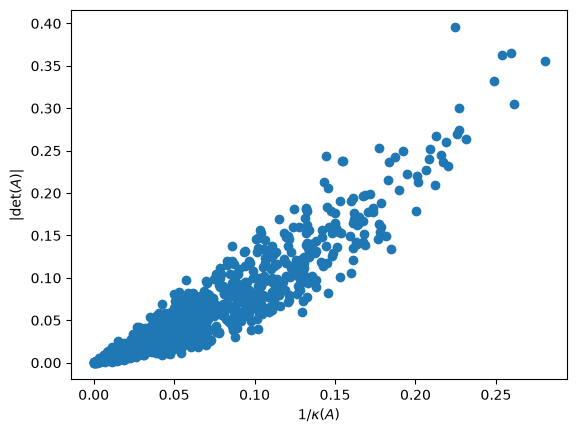

In [36]:
import numpy as np
import matplotlib.pyplot as plt


def det_LU(A):
    A = A.copy()
    n = A.shape[0]

    for k in range(n - 1):
        for i in range(k + 1, n):
            m = A[i, k] / A[k, k]
            A[i, k:] = A[i, k:] - m * A[k, k:]

    return np.prod(np.diag(A))

det_values = []
inv_cond_values = []

for i in range(1000):

    A = np.random.rand(4, 4)
    A = A / np.linalg.norm(A, axis=0)

    det_A = det_LU(A)

    cond_A = np.linalg.cond(A)

    det_values.append(abs(det_A))
    inv_cond_values.append(1 / cond_A)

plt.scatter(inv_cond_values, det_values)
plt.xlabel(r'$1/\kappa(A)$')
plt.ylabel(r'$|\det(A)|$')
plt.show()

In [ ]:
inv_cond_values

In [39]:
print(f"min. det = {min(det_values)}, and corresponding k = {inv_cond_values[det_values.index(min(det_values))]}, max. det = {max(det_values)}, and corresponding k = {inv_cond_values[det_values.index(max(det_values))]}")



min. det = 3.181008920295286e-05, and corresponding k = 7.545382662272349e-05, max. det = 0.396122966318929, and corresponding k = 0.2248095617476819


In [40]:
301 * (4.01)

1207.01

In [44]:
np.array([3, 6.01]) - np.matmul(np.array([[1, 2], [2, 4.01]]), np.array([-600, 301]))

array([ 1., -1.])

In [46]:
601 / (1/ 6.01)

3612.0099999999998

## 17

Carry out the steps of Computer Problem 1 with n = 100 for (a) Gauss–Seidel Method

[
    
    3 -1 


    -1 3 -1

]

In [70]:
import numpy as np


def row(i):
    if i == 0:
        return np.array([3, -1] + [0] * 98)
    elif i < 99:
        return np.array([0] * (i - 1) + [-1, 3, -1] + [0] * (98 - i))
    return np.array([0] * 98 + [-1, 3])


A = np.array([row(i) for i in range(100)])

x_exact = np.ones(100)

b = A @ x_exact


def Gauss_Seidel(A, b, x0, n):
    x = x0.copy()

    for k in range(n):
        for i in range(len(b)):
            s1 = np.dot(A[i, :i], x[:i])

            s2 = np.dot(A[i, i+1:], x[i+1:])

            x[i] = (b[i] - s1 - s2) / A[i, i]

    return x


Gauss_Seidel(A, b, np.zeros(100, dtype=float), 20)


array([0.99999952, 0.99999928, 0.99999916, 0.9999991 , 0.99999908,
       0.99999906, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999905,
       0.99999905, 0.99999905, 0.99999905, 0.99999905, 0.99999

$\times$

In [60]:
3*98 + 2+ 2

298

## 19



In [28]:


Vandermond(x)

array([[ 1.,  0.,  0.,  0.],
       [ 1.,  1.,  1.,  1.],
       [ 1.,  2.,  4.,  8.],
       [ 1.,  3.,  9., 27.]])

[ 1.   9.  -7.5  1.5]
p(x_k): [1. 4. 1. 1.]
y_k:    [1. 4. 1. 1.]


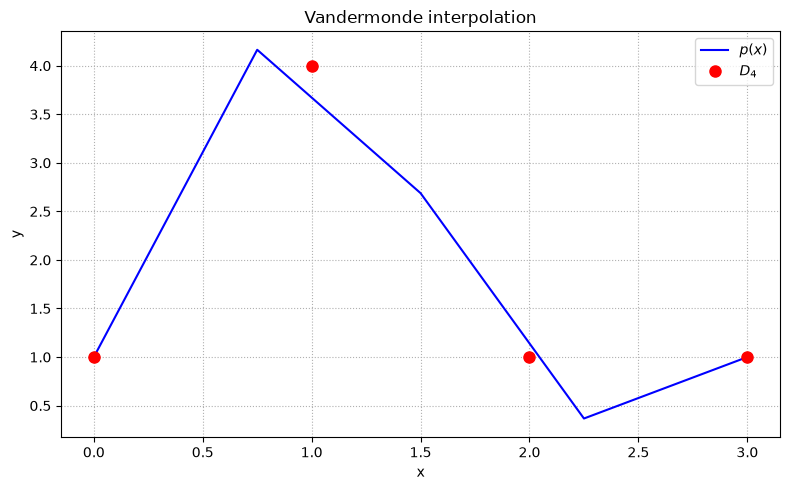

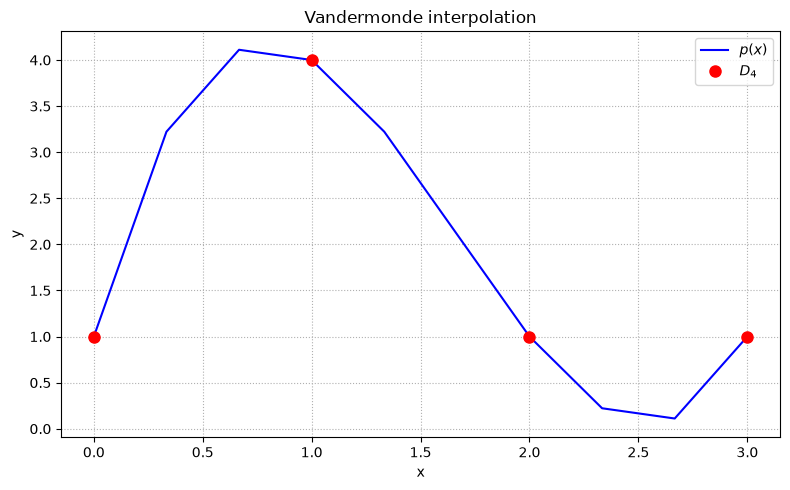

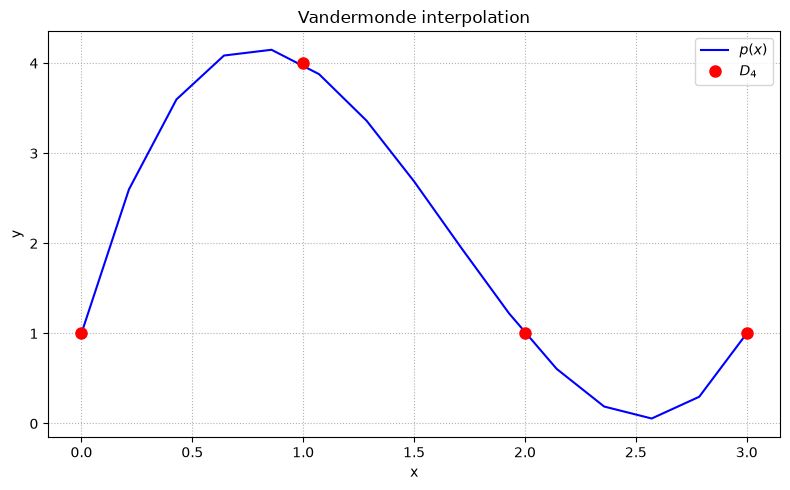

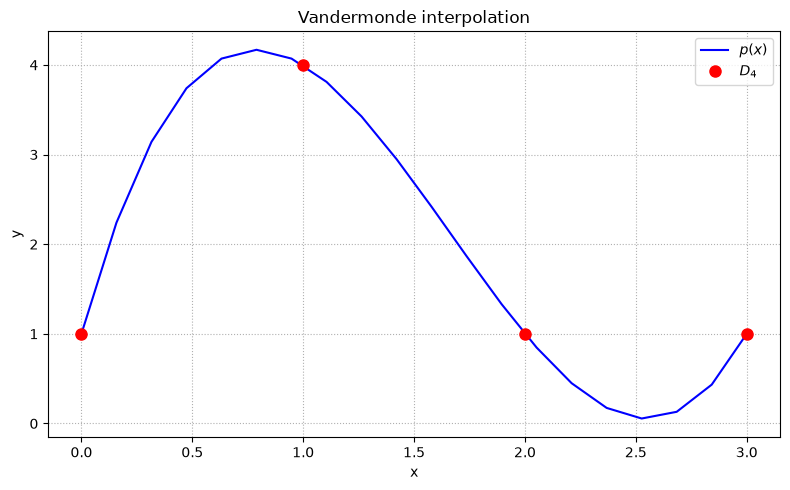

In [71]:
import numpy as np
import matplotlib.pyplot as plt

def Vandermond(x: np.ndarray) -> np.ndarray:
    n = len(x)
    return np.array([[x[i]**j for j in range(n)] for i in range(n)])

def get_coeffs(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    V = Vandermond(x)
    return np.linalg.solve(V, y)


x = np.array([0, 1, 2, 3], dtype=float)
y = np.array([1, 4, 1, 1], dtype=float)

coeffs = get_coeffs(x, y)
print(coeffs)


print("p(x_k):", Vandermond(x) @ coeffs)
print("y_k:   ", y)


for N in [5, 10, 15, 20]:
    x_fine = np.linspace(0, 3, N)

    n = len(x)
    y_fine = np.array([
        sum(coeffs[j] * xi**j for j in range(n))
        for xi in x_fine
    ])

    plt.figure(figsize=(8, 5))
    plt.plot(x_fine, y_fine, 'b-', label=r'$p(x)$')
    plt.plot(x, y, 'ro', markersize=8, label=r'$D_4$')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Vandermonde interpolation')
    plt.grid(True, ls=':')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [44]:
for n in [5, 10, 15, 20]:
    points = np.linspace(0, 1, n)
    V = Vandermond(points)
    condition_number = np.linalg.cond(V, np.inf)
    print(f"Condition number for {n} points: {condition_number}")



Condition number for 5 points: 1706.6666666666665
Condition number for 10 points: 48183984.002129205
Condition number for 15 points: 1605542347896.6553
Condition number for 20 points: 4.984423385657521e+16


## 21

Write a function that computes coefficients of Newton’s interpolant along with your own routine
for evaluation (using nested polynomial method, Horner’s rule) to find and plot the polynomial
that is zero at x = 1, 2, 4, 5, . . . , 10, 11 and satisfies p(3) = 1. Note that this is the Lagrange’s basis
function L3(x) for the set of nodal points {xj}
11
j=1 = {1, 2, 3, . . . , 11}.

Newton coefficients: [ 0.00000000e+00  0.00000000e+00  5.00000000e-01 -5.00000000e-01
  2.50000000e-01 -8.33333333e-02  2.08333333e-02 -4.16666667e-03
  6.94444444e-04 -9.92063492e-05  1.24007937e-05]
p(3) = 1.0


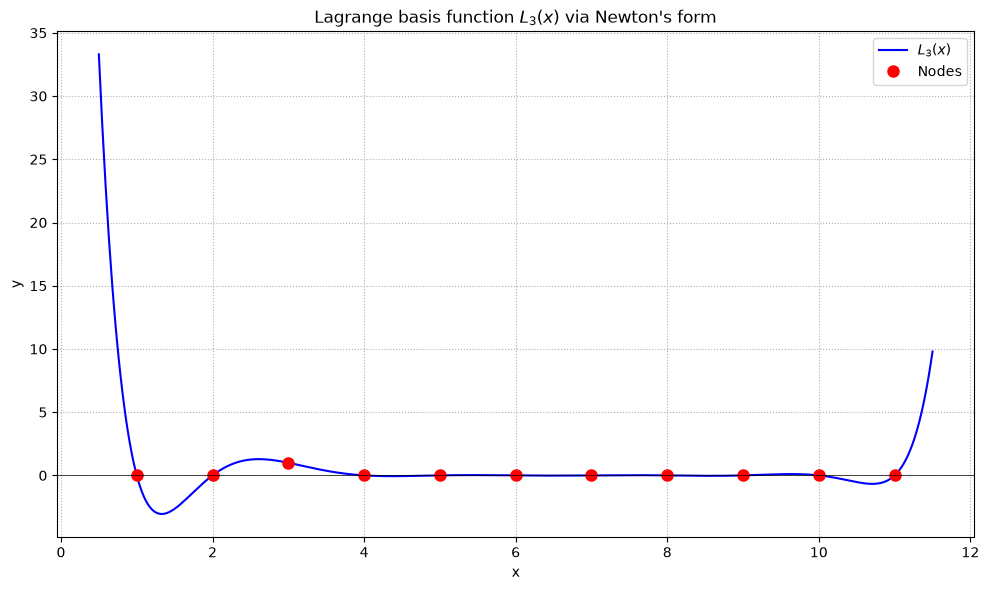

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def newton_coeffs(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    n = len(x)
    c = y.astype(float).copy()
    for j in range(1, n):
        for i in range(n - 1, j - 1, -1):
            c[i] = (c[i] - c[i - 1]) / (x[i] - x[i - j])
    return c


def newton_eval(x_nodes: np.ndarray, c: np.ndarray, x_eval: float) -> float:
    result = c[-1]
    for i in range(len(c) - 2, -1, -1):
        result = result * (x_eval - x_nodes[i]) + c[i]
    return result


x = np.arange(1, 12, dtype=float)
y = np.zeros(11)
y[2] = 1.0

c = newton_coeffs(x, y)
print("Newton coefficients:", c)


p3 = newton_eval(x, c, 3.0)
print(f"p(3) = {p3}")


x_fine = np.linspace(0.5, 11.5, 500)
y_fine = np.array([newton_eval(x, c, xi) for xi in x_fine])

plt.figure(figsize=(10, 6))
plt.plot(x_fine, y_fine, 'b-', label=r'$L_3(x)$')
plt.plot(x, y, 'ro', markersize=8, label='Nodes')
plt.axhline(y=0, color='k', linewidth=0.5)
plt.xlabel('x')
plt.ylabel('y')
plt.title("Lagrange basis function $L_3(x)$ via Newton's form")
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()


## 22

Use your routines from Problem 19 to interpolate the data sets {(xj , yj ) : j = 1, . . . , n}, where
yj = f(xj ) with f(x) = 1/(x
2 + 1).
1. xj = −4 + 8 j − 1
n − 1
, n = 11.
2. xj = 4 cos π(2j − 1)
2n
, n = 11.
In each case, return 3 plots:
• The data and the interpolant on [−4, 4]. The interpolants should be plotted on a dense
collection of points, say 500 equally spaced points. Include on your plots markers of some
kind that illustrate the data points.
• The error e(x) = f(x) − p(x) for x ∈ [−4, 4].
• The function g(x) = 1
n!
Yn
k=1
(x − xk) for x ∈ [−4, 4].
Discuss your results.

In [47]:
import math

math.factorial(5)

120

coeffs: [ 1.00000000e+00  1.33540235e-14 -7.94975110e-01 -1.78135606e-15
  3.26105255e-01 -1.02144671e-15 -6.03623756e-02  1.75910770e-16
  4.80012775e-03 -6.77326177e-18 -1.32600214e-04]
p(x_k): [0.05882353 0.08896797 0.14792899 0.28089888 0.6097561  1.
 0.6097561  0.28089888 0.14792899 0.08896797 0.05882353]
y_k:    [0.05882353 0.08896797 0.14792899 0.28089888 0.6097561  1.
 0.6097561  0.28089888 0.14792899 0.08896797 0.05882353]


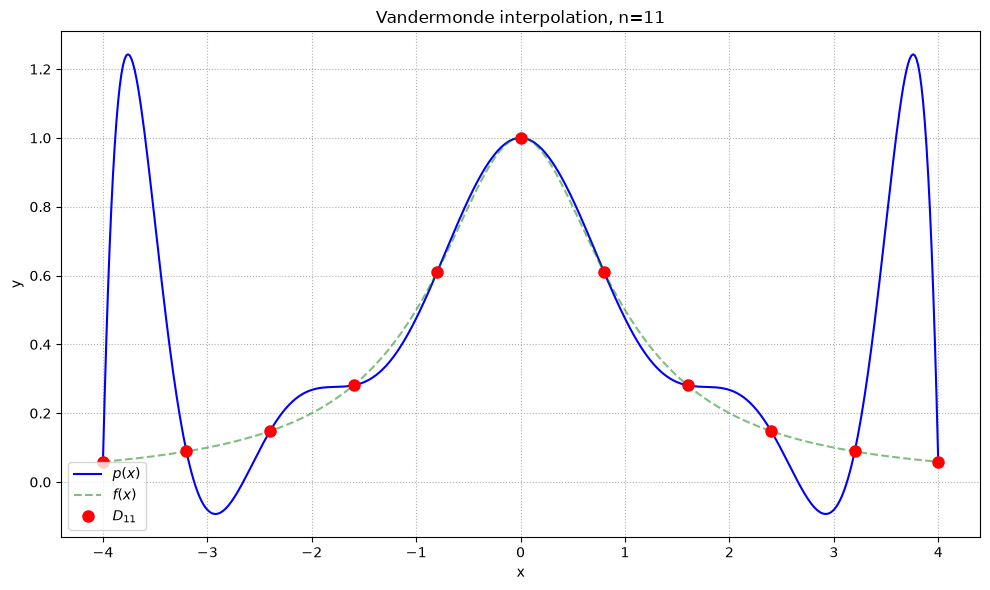

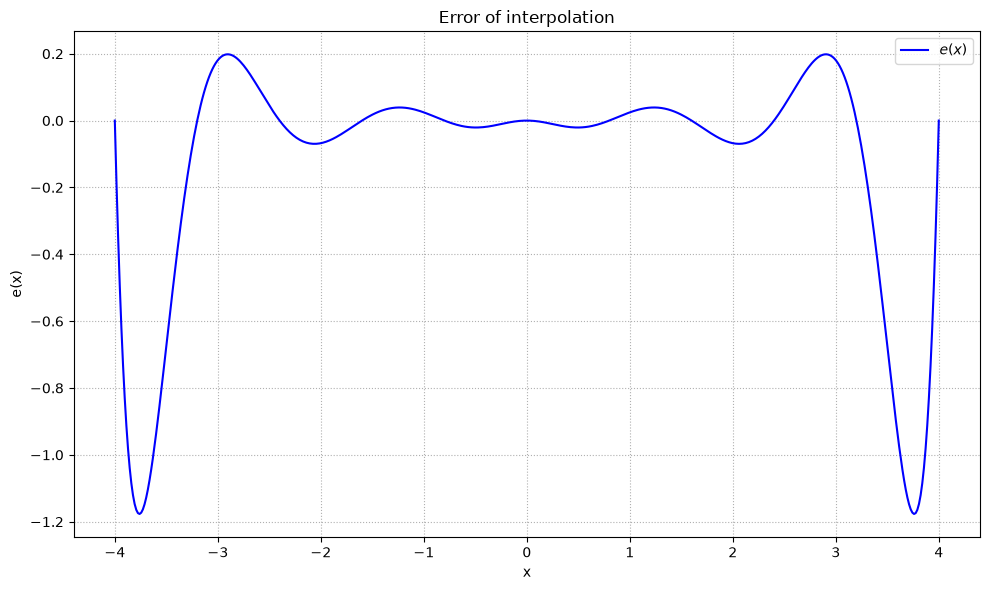

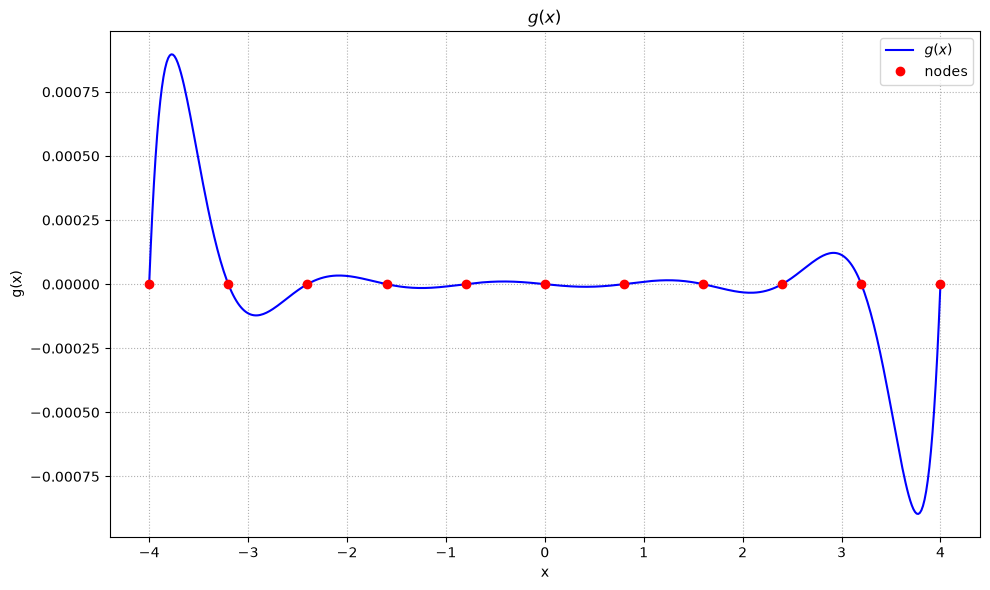

In [58]:
import math

def f(x):
    return 1 / (x ** 2 + 1)

def g(x, x_nodes: np.ndarray):
    return (np.prod([x - x_node for x_node in x_nodes], axis=0))/ math.factorial(len(x_nodes))


# case 1

n = 11

x = np.array([-4 + 8 * j / (n - 1) for j in range(0, n)], dtype=float)
y = f(x)
coeffs = get_coeffs(x, y)
print("coeffs:", coeffs)

print("p(x_k):", Vandermond(x) @ coeffs)
print("y_k:   ", y)


x_fine = np.linspace(-4, 4, 500)
y_fine = np.array([
    sum(coeffs[j] * xi**j for j in range(len(coeffs)))
    for xi in x_fine
])

plt.figure(figsize=(10, 6))
plt.plot(x_fine, y_fine, 'b-', label=r'$p(x)$')
plt.plot(x_fine, f(x_fine), 'g--', alpha=0.5, label=r'$f(x)$')
plt.plot(x, y, 'ro', markersize=8, label=r'$D_{11}$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Vandermonde interpolation, n=11')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()


error = f(x_fine) - y_fine

plt.figure(figsize=(10, 6))
plt.plot(x_fine, error, 'b-', label=r'$e(x)$')
plt.xlabel('x')
plt.ylabel('e(x)')
plt.title('Error of interpolation')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(x_fine, g(x_fine, x), 'b-', label=r'$g(x)$')
plt.plot(x, np.zeros_like(x), 'ro', markersize=6, label='nodes')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('$g(x)$')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()

[ 1.00000000e+00  7.26103667e-15 -6.36891138e-01 -7.70666829e-15
  1.83005061e-01  1.78764336e-15 -2.41449341e-02 -1.52245563e-16
  1.45063022e-03  4.31775803e-18 -3.22362271e-05]
coeffs: [ 1.00000000e+00  7.26103667e-15 -6.36891138e-01 -7.70666829e-15
  1.83005061e-01  1.78764336e-15 -2.41449341e-02 -1.52245563e-16
  1.45063022e-03  4.31775803e-18 -3.22362271e-05]
p(x_k): [0.05996662 0.07023021 0.09863374 0.17615931 0.44053412 1.
 0.44053412 0.17615931 0.09863374 0.07023021 0.05996662]
y_k:    [0.0599666209395999, 0.07023021386786919, 0.09863373821955115, 0.17615930760994564, 0.440534119234089, 1.0, 0.4405341192340892, 0.1761593076099459, 0.09863373821955117, 0.07023021386786922, 0.0599666209395999]


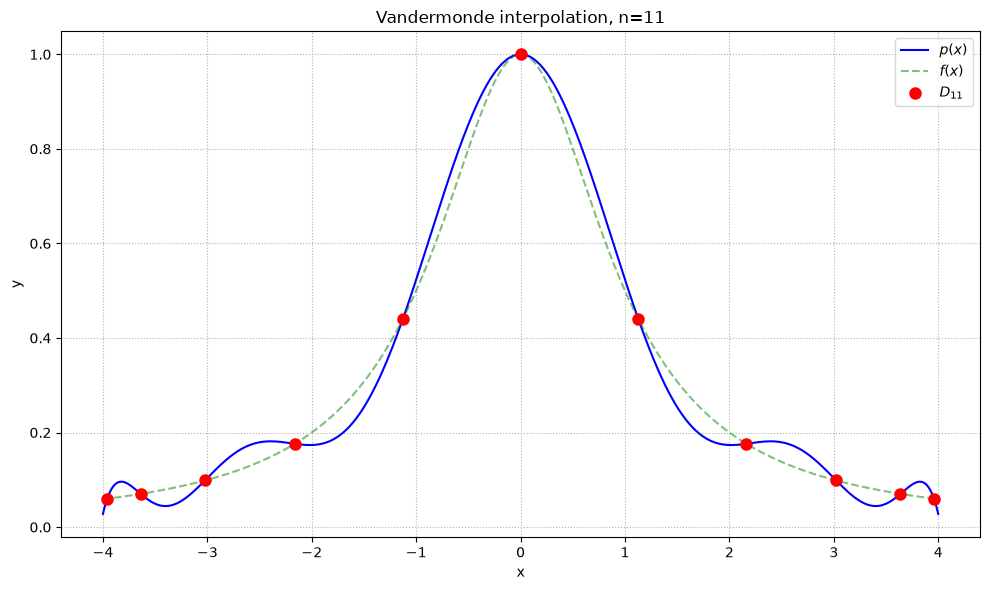

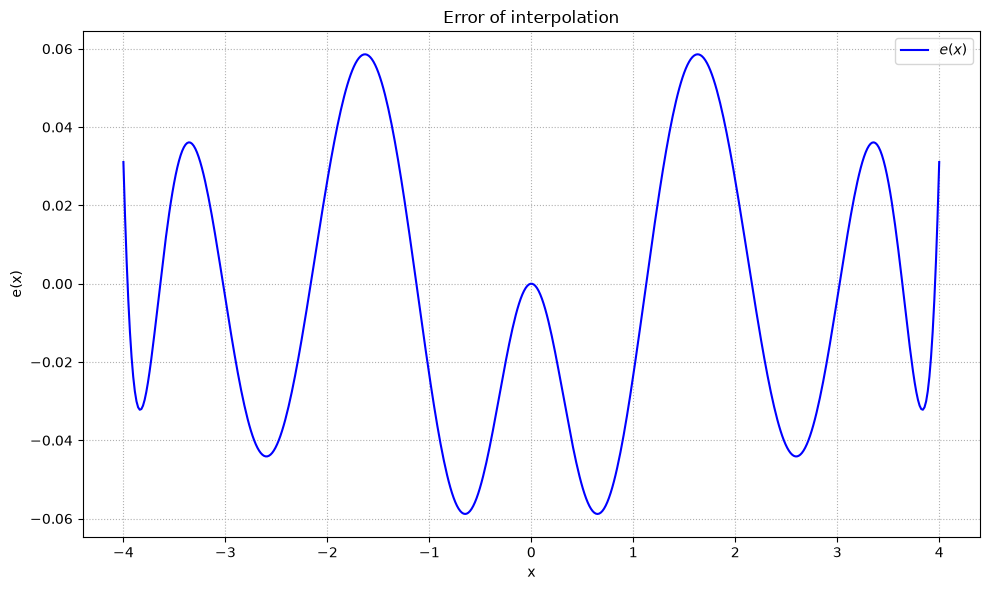

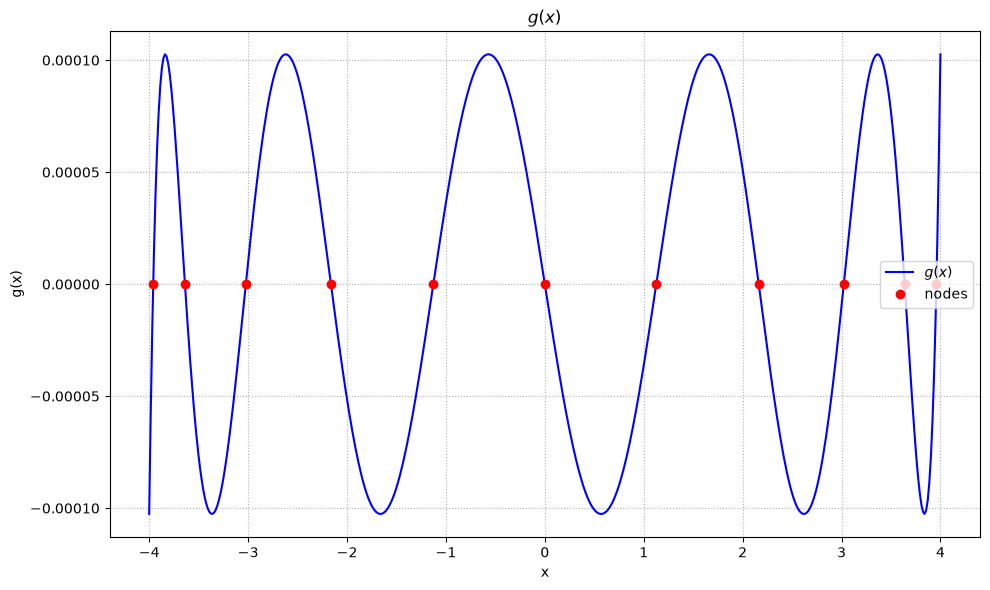

In [59]:
# case 2
import numpy as np

x = [4 * np.cos(np.pi * (2 * j - 1) / (2 * n)) for j in range(1, n + 1)]
y = [f(x) for x in x]
coeffs = get_coeffs(x, y)
print(coeffs)


print("coeffs:", coeffs)

print("p(x_k):", Vandermond(x) @ coeffs)
print("y_k:   ", y)


x_fine = np.linspace(-4, 4, 500)
y_fine = np.array([
    sum(coeffs[j] * xi**j for j in range(len(coeffs)))
    for xi in x_fine
])

plt.figure(figsize=(10, 6))
plt.plot(x_fine, y_fine, 'b-', label=r'$p(x)$')
plt.plot(x_fine, f(x_fine), 'g--', alpha=0.5, label=r'$f(x)$')
plt.plot(x, y, 'ro', markersize=8, label=r'$D_{11}$')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Vandermonde interpolation, n=11')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()


error = f(x_fine) - y_fine

plt.figure(figsize=(10, 6))
plt.plot(x_fine, error, 'b-', label=r'$e(x)$')
plt.xlabel('x')
plt.ylabel('e(x)')
plt.title('Error of interpolation')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
plt.plot(x_fine, g(x_fine, x), 'b-', label=r'$g(x)$')
plt.plot(x, np.zeros_like(x), 'ro', markersize=6, label='nodes')
plt.xlabel('x')
plt.ylabel('g(x)')
plt.title('$g(x)$')
plt.grid(True, ls=':')
plt.legend()
plt.tight_layout()
plt.show()